In [2]:
import os

classes = os.listdir("../data/raw/PlantVillage")
print(f" Total classes found : {len(classes)}")
print("\n".join(sorted(classes)))

 Total classes found : 16
Pepper__bell___Bacterial_spot
Pepper__bell___healthy
PlantVillage
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato__Tomato_mosaic_virus
Tomato_healthy


                                      Class  Count
                           Potato___healthy    152
                Tomato__Tomato_mosaic_virus    373
                           Tomato_Leaf_Mold    952
              Pepper__bell___Bacterial_spot    997
                        Tomato_Early_blight   1000
                      Potato___Early_blight   1000
                       Potato___Late_blight   1000
                        Tomato__Target_Spot   1404
                     Pepper__bell___healthy   1478
                             Tomato_healthy   1591
Tomato_Spider_mites_Two_spotted_spider_mite   1676
                  Tomato_Septoria_leaf_spot   1771
                         Tomato_Late_blight   1909
                      Tomato_Bacterial_spot   2127
      Tomato__Tomato_YellowLeaf__Curl_Virus   3208

Total images: 20638
Min: 152 | Max: 3208


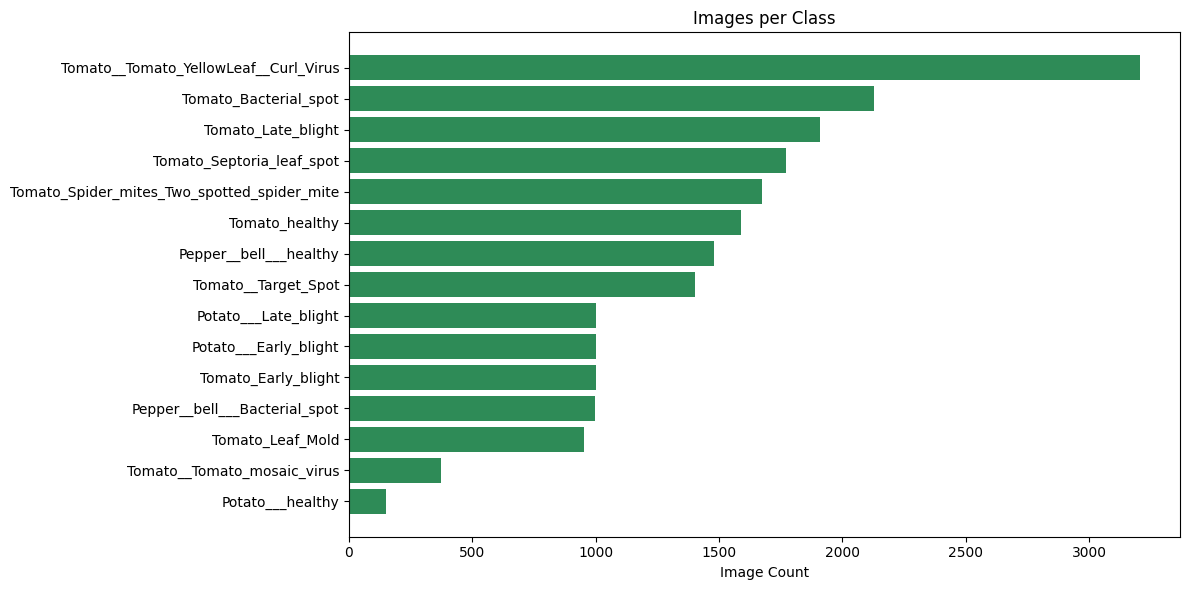

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

base_path = "../data/raw/PlantVillage"

# Count images per class
class_counts = {}
for cls in sorted(os.listdir(base_path)):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path) and cls != "PlantVillage":
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        class_counts[cls] = len(images)

# Summary
df = pd.DataFrame(class_counts.items(), columns=["Class", "Count"]).sort_values("Count")
print(df.to_string(index=False))
print(f"\nTotal images: {df['Count'].sum()}")
print(f"Min: {df['Count'].min()} | Max: {df['Count'].max()}")

# Bar chart
plt.figure(figsize=(12, 6))
plt.barh(df["Class"], df["Count"], color="seagreen")
plt.xlabel("Image Count")
plt.title("Images per Class")
plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

# ── 1. Collect all image paths + labels ──────────────────────────────────────
base_path = "../data/raw/PlantVillage"

all_images, all_labels = [], []
class_names = sorted([
    d for d in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, d))
])
class_to_idx = {cls: i for i, cls in enumerate(class_names)}

for cls in class_names:
    cls_path = os.path.join(base_path, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(cls_path, fname))
            all_labels.append(class_to_idx[cls])

# ── 2. Stratified Split (70 / 15 / 15) ───────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels, test_size=0.30,
    stratify=all_labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ── 3. Transforms ─────────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])  # ImageNet stats
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── 4. Dataset Class ──────────────────────────────────────────────────────────
class PlantDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_dataset = PlantDataset(X_train, y_train, train_transforms)
val_dataset   = PlantDataset(X_val,   y_val,   val_test_transforms)
test_dataset  = PlantDataset(X_test,  y_test,  val_test_transforms)

# ── 5. Weighted Sampler (handles imbalance during training) ───────────────────
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in y_train]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ── 6. DataLoaders ────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=32,
                          sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32,
                          shuffle=False,  num_workers=4, pin_memory=True)

print("DataLoaders ready ✅")
print(f"Classes: {class_names}")

In [1]:
import onnxruntime as ort

print(f" the providers are {ort.get_available_providers()}")

 the providers are ['AzureExecutionProvider', 'CPUExecutionProvider']
